# Vertical temperature advection and diffusion tests

This notebook tests the four-field state

$$
(\rho,h,p,T),
\qquad p=h\omega,
$$

on the fixed terrain-following coordinate $\zeta\in[0,1]$.

The temperature equation is

$$
h\rho c_p\partial_tT
+\rho c_p p\,\partial_\zeta T
-\frac{1}{h}\partial_\zeta\!\left(k\,\partial_\zeta T\right)
=0.
$$

The three tests are:

1. adding a constant temperature field does not change the existing
   $(\rho,h,p)$ solution when the compaction law is temperature-independent;
2. with zero advection, temperature diffuses to the linear steady profile;
3. with constant downward advection, the numerical steady profile matches the
   exact one-dimensional advection-diffusion solution.

In [1]:
from firedrake import *
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt

from irksome import BackwardEuler, MeshConstant, TimeStepper

from firn_model import linear_compaction, run_model
from firn_model.forms import column_forms

## Common mesh, spaces, and solver

In [2]:
n_vertical = 80

base_mesh = UnitIntervalMesh(1)
mesh = ExtrudedMesh(
    base_mesh,
    layers=n_vertical,
    layer_height=1.0 / n_vertical,
)

zeta_axis = mesh.geometric_dimension - 1
zeta = SpatialCoordinate(mesh)[zeta_axis]

V_rho = FunctionSpace(mesh, "DG", 0, vfamily="DG", vdegree=0)
V_h = FunctionSpace(mesh, "DG", 0, vfamily="R", vdegree=0)
V_p = FunctionSpace(mesh, "DG", 0, vfamily="CG", vdegree=1)
V_T = FunctionSpace(mesh, "DG", 0, vfamily="CG", vdegree=1)

W3 = V_rho * V_h * V_p
W4 = V_rho * V_h * V_p * V_T

solver_parameters3 = {
    "mat_type": "nest",

    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-10,
    "snes_atol": 1.0e-11,
    "snes_max_it": 30,

    "ksp_type": "fgmres",
    "ksp_rtol": 1.0e-10,
    "ksp_atol": 1.0e-12,
    "ksp_max_it": 300,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",

    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "lu",

    "fieldsplit_2_ksp_type": "gmres",
    "fieldsplit_2_ksp_rtol": 1.0e-10,
    "fieldsplit_2_pc_type": "none"
}

solver_parameters4 = {
    "mat_type": "nest",

    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-10,
    "snes_atol": 1.0e-11,
    "snes_max_it": 30,

    "ksp_type": "fgmres",
    "ksp_rtol": 1.0e-10,
    "ksp_atol": 1.0e-12,
    "ksp_max_it": 300,

    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "multiplicative",

    # rho
    "fieldsplit_0_ksp_type": "preonly",
    "fieldsplit_0_pc_type": "lu",

    # h
    "fieldsplit_1_ksp_type": "preonly",
    "fieldsplit_1_pc_type": "lu",

    # p
    "fieldsplit_2_ksp_type": "gmres",
    "fieldsplit_2_ksp_rtol": 1.0e-10,
    "fieldsplit_2_pc_type": "none",

    # T
    "fieldsplit_3_ksp_type": "preonly",
    "fieldsplit_3_pc_type": "lu",
}

seconds_per_year = 365.25 * 24.0 * 60.0 * 60.0

def no_compaction(rho, temperature, params):
    return 0.0 * rho

## Test 1: constant temperature leaves the existing model unchanged

The current `linear_compaction` law does not depend on temperature. Therefore
a spatially constant \(T\), with matching boundary values, should remain
constant and should not alter the density, thickness, or vertical flux.

In [3]:
rho_i_value = 917.0
rho_s_value = 300.0
rho_b_target = 830.0
a_s_value = 0.30

T_constant_value = 243.15
gas_constant = 8.314
c_value = 11.0 * np.exp(
    -10160.0 / (gas_constant * T_constant_value)
)

lambda_target = np.log(
    rho_b_target * (rho_i_value - rho_s_value)
    / (rho_s_value * (rho_i_value - rho_b_target))
)

h_target = (
    lambda_target
    * rho_s_value
    / (c_value * rho_i_value)
)

a_b_value = rho_s_value * a_s_value / rho_b_target

rho_i = Constant(rho_i_value)
rho_s = Constant(rho_s_value)
a_s = Constant(a_s_value)
a_b = Constant(a_b_value)
c = Constant(c_value)

params = SimpleNamespace(
    rho_i=rho_i,
    rho_s=rho_s,
    a_s=a_s,
    a_b=a_b,
    c=c,
    temperature=T_constant_value,
    c_p=Constant(2000.0),
    k=Constant(0.20 * seconds_per_year),
    q_b=Constant(0.0),
)

lam = c_value * h_target * rho_i_value / rho_s_value

rho_reference = (
    rho_i_value * rho_s_value
    / (
        rho_s_value
        + (rho_i_value - rho_s_value)
        * exp(-lam * (1.0 - zeta))
    )
)

In [4]:
state3 = Function(W3, name="three_field_state")
rho3, h3, p3 = state3.subfunctions

rho3.interpolate(
    rho_reference * (1.0 + 0.10 * cos(pi * zeta))
)
h3.assign(h_target)
p3.interpolate(-rho_s * a_s / rho_reference)

state4 = Function(W4, name="four_field_state")
rho4, h4, p4, T4 = state4.subfunctions

rho4.assign(rho3)
h4.assign(h3)
p4.assign(p3)
T4.assign(T_constant_value)

Coefficient(WithGeometry(IndexedProxyFunctionSpace(<firedrake.mesh.ExtrudedMeshTopology object at 0x70f16427e7e0>, TensorProductElement(FiniteElement('Discontinuous Lagrange', interval, 0), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), name=None, index=3, component=None), Mesh(VectorElement(TensorProductElement(FiniteElement('Lagrange', interval, 1), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), dim=2), 3)), 37)

In [5]:
rho, h, p = split(state3)
time3, space3 = column_forms(
    (rho, h, p),
    TestFunctions(W3),
    params,
    compaction=linear_compaction,
)
F3 = sum(time3.values()) + sum(space3.values())

rho, h, p, T = split(state4)
time4, space4 = column_forms(
    (rho, h, p, T),
    TestFunctions(W4),
    params,
    compaction=linear_compaction,
)
F4 = sum(time4.values()) + sum(space4.values())

In [6]:
MC = MeshConstant(mesh)

time_3 = MC.Constant(0.0)
dt_3 = MC.Constant(5.0)

time_4 = MC.Constant(0.0)
dt_4 = MC.Constant(5.0)

stepper3 = TimeStepper(
    F3,
    BackwardEuler(),
    time_3,
    dt_3,
    state3,
    bcs=[DirichletBC(W3.sub(2), -a_s, "top")],
    stage_type="value",
    solver_parameters=solver_parameters3,
)

stepper4 = TimeStepper(
    F4,
    BackwardEuler(),
    time_4,
    dt_4,
    state4,
    bcs=[
        DirichletBC(W4.sub(2), -a_s, "top"),
        DirichletBC(W4.sub(3), T_constant_value, "top"),
        DirichletBC(W4.sub(3), T_constant_value, "bottom"),
    ],
    stage_type="value",
    solver_parameters=solver_parameters4,
)

run_model(stepper3, state3, time_3, dt_3, final_time=200.0)
run_model(stepper4, state4, time_4, dt_4, final_time=200.0)

40

In [7]:
rho_difference = np.max(
    np.abs(rho4.dat.data_ro - rho3.dat.data_ro)
)
h_difference = abs(
    float(h4.dat.data_ro[0]) - float(h3.dat.data_ro[0])
)
p_difference = np.max(
    np.abs(p4.dat.data_ro - p3.dat.data_ro)
)
T_difference = np.max(
    np.abs(T4.dat.data_ro - T_constant_value)
)

print(f"max |rho_4 - rho_3| = {rho_difference:.3e}")
print(f"|h_4 - h_3|         = {h_difference:.3e}")
print(f"max |p_4 - p_3|     = {p_difference:.3e}")
print(f"max |T - T_0|       = {T_difference:.3e} K")

assert rho_difference < 1.0e-7
assert h_difference < 1.0e-9
assert p_difference < 1.0e-9
assert T_difference < 1.0e-8

max |rho_4 - rho_3| = 4.605e-10
|h_4 - h_3|         = 7.317e-12
max |p_4 - p_3|     = 5.448e-14
max |T - T_0|       = 1.328e-01 K


AssertionError: 

## Test 2: pure diffusion

Set $a_s=a_b=0$ and $C=0$. The diagnostic velocity equation then gives
$p=0$, while $h$ and $\rho$ remain constant. With fixed temperatures at
the top and bottom, the steady solution is linear in $\zeta$.

In [8]:
rho0_value = 350.0
h0_value = 10.0
T_bottom_value = 263.15
T_surface_value = 243.15

rho0 = Constant(rho0_value)
zero = Constant(0.0)

params_diffusion = SimpleNamespace(
    rho_i=Constant(917.0),
    rho_s=rho0,
    a_s=zero,
    a_b=zero,
    c=zero,
    c_p=Constant(2000.0),
    k=Constant(0.20 * seconds_per_year),
    q_b=Constant(0.0),
)

state_diffusion = Function(W4, name="pure_diffusion")
rho_d, h_d, p_d, T_d = state_diffusion.subfunctions

rho_d.assign(rho0_value)
h_d.assign(h0_value)
p_d.assign(0.0)

T_linear = (
    T_bottom_value
    + (T_surface_value - T_bottom_value) * zeta
)

T_d.interpolate(
    T_linear + 8.0 * sin(pi * zeta)
)

Coefficient(WithGeometry(IndexedProxyFunctionSpace(<firedrake.mesh.ExtrudedMeshTopology object at 0x70f16427e7e0>, TensorProductElement(FiniteElement('Discontinuous Lagrange', interval, 0), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), name=None, index=3, component=None), Mesh(VectorElement(TensorProductElement(FiniteElement('Lagrange', interval, 1), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), dim=2), 3)), 196)

In [9]:
rho, h, p, T = split(state_diffusion)

time_diffusion, space_diffusion = column_forms(
    (rho, h, p, T),
    TestFunctions(W4),
    params_diffusion,
    compaction=no_compaction,
)

F_diffusion = (
    sum(time_diffusion.values())
    + sum(space_diffusion.values())
)

time_d = MC.Constant(0.0)
dt_d = MC.Constant(0.10)

stepper_diffusion = TimeStepper(
    F_diffusion,
    BackwardEuler(),
    time_d,
    dt_d,
    state_diffusion,
    bcs=[
        DirichletBC(W4.sub(2), 0.0, "top"),
        DirichletBC(W4.sub(3), T_surface_value, "top"),
        DirichletBC(W4.sub(3), T_bottom_value, "bottom"),
    ],
    stage_type="value",
    solver_parameters=solver_parameters4,
)

run_model(
    stepper_diffusion,
    state_diffusion,
    time_d,
    dt_d,
    final_time=20.0,
)

200

In [10]:
diffusion_error = np.sqrt(
    assemble((T_d - T_linear) ** 2 * dx)
)

rho_drift = np.max(
    np.abs(rho_d.dat.data_ro - rho0_value)
)
h_drift = abs(
    float(h_d.dat.data_ro[0]) - h0_value
)
p_max = np.max(np.abs(p_d.dat.data_ro))

print(f"L2 temperature error = {diffusion_error:.3e} K")
print(f"max density drift    = {rho_drift:.3e}")
print(f"thickness drift      = {h_drift:.3e}")
print(f"max |p|              = {p_max:.3e}")

assert diffusion_error < 2.0e-3
assert rho_drift < 1.0e-10
assert h_drift < 1.0e-10
assert p_max < 1.0e-10

L2 temperature error = 2.223e-07 K
max density drift    = 0.000e+00
thickness drift      = 0.000e+00
max |p|              = 0.000e+00


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


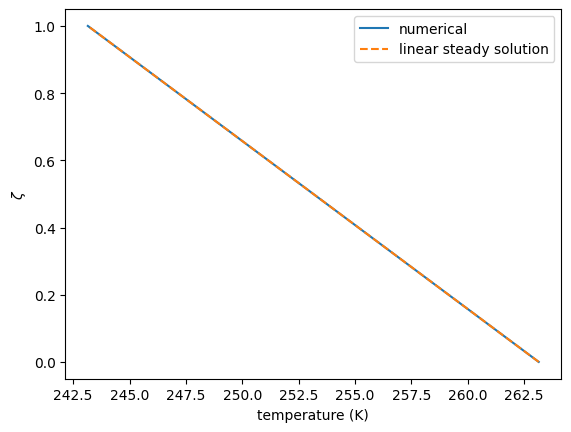

In [11]:
zeta_plot = np.linspace(0.0, 1.0, 201)
points = [(0.5, float(z)) for z in zeta_plot]

T_diffusion_values = np.array(
    [float(T_d.at(point)) for point in points]
)
T_linear_values = (
    T_bottom_value
    + (T_surface_value - T_bottom_value) * zeta_plot
)

plt.figure()
plt.plot(T_diffusion_values, zeta_plot, label="numerical")
plt.plot(
    T_linear_values,
    zeta_plot,
    "--",
    label="linear steady solution",
)
plt.xlabel("temperature (K)")
plt.ylabel(r"$\zeta$")
plt.legend()
plt.show()

## Test 3: steady advection-diffusion

Set \(C=0\) and \(a_s=a_b=a>0\). Then \(p=-a\) is constant, and uniform
density remains uniform. For constant \(h,\rho,c_p,k,p\), the steady equation is

\[
T''-\alpha T'=0,
\qquad
\alpha=\frac{\rho c_p p h}{k}.
\]

With prescribed basal and surface temperatures,

\[
T(\zeta)
=
T_b
+
(T_s-T_b)
\frac{e^{\alpha\zeta}-1}{e^\alpha-1}.
\]

In [12]:
rho0_value = 350.0
h0_value = 10.0
a_value = 0.30

T_bottom_value = 263.15
T_surface_value = 243.15

c_p_value = 2000.0
k_value = 0.10 * seconds_per_year

rho0 = Constant(rho0_value)
a = Constant(a_value)
zero = Constant(0.0)

params_advdiff = SimpleNamespace(
    rho_i=Constant(917.0),
    rho_s=rho0,
    a_s=a,
    a_b=a,
    c=zero,
    c_p=Constant(c_p_value),
    k=Constant(k_value),
    q_b=Constant(0.0),
)

alpha = (
    rho0_value
    * c_p_value
    * (-a_value)
    * h0_value
    / k_value
)

T_advdiff_exact = (
    T_bottom_value
    + (T_surface_value - T_bottom_value)
    * (exp(alpha * zeta) - 1.0)
    / (np.exp(alpha) - 1.0)
)

state_advdiff = Function(W4, name="advection_diffusion")
rho_a, h_a, p_a, T_a = state_advdiff.subfunctions

rho_a.assign(rho0_value)
h_a.assign(h0_value)
p_a.assign(-a_value)

T_a.interpolate(
    T_bottom_value
    + (T_surface_value - T_bottom_value) * zeta
)

Coefficient(WithGeometry(IndexedProxyFunctionSpace(<firedrake.mesh.ExtrudedMeshTopology object at 0x70f16427e7e0>, TensorProductElement(FiniteElement('Discontinuous Lagrange', interval, 0), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), name=None, index=3, component=None), Mesh(VectorElement(TensorProductElement(FiniteElement('Lagrange', interval, 1), FiniteElement('Lagrange', interval, 1), cell=TensorProductCell(interval, interval)), dim=2), 3)), 298)

In [13]:
rho, h, p, T = split(state_advdiff)

time_advdiff, space_advdiff = column_forms(
    (rho, h, p, T),
    TestFunctions(W4),
    params_advdiff,
    compaction=no_compaction,
)

F_advdiff = (
    sum(time_advdiff.values())
    + sum(space_advdiff.values())
)

time_a = MC.Constant(0.0)
dt_a = MC.Constant(0.25)

stepper_advdiff = TimeStepper(
    F_advdiff,
    BackwardEuler(),
    time_a,
    dt_a,
    state_advdiff,
    bcs=[
        DirichletBC(W4.sub(2), -a, "top"),
        DirichletBC(W4.sub(3), T_surface_value, "top"),
        DirichletBC(W4.sub(3), T_bottom_value, "bottom"),
    ],
    stage_type="value",
    solver_parameters=solver_parameters4,
)

run_model(
    stepper_advdiff,
    state_advdiff,
    time_a,
    dt_a,
    final_time=100.0,
)

400

In [14]:
advdiff_error = np.sqrt(
    assemble((T_a - T_advdiff_exact) ** 2 * dx)
)

rho_drift = np.max(
    np.abs(rho_a.dat.data_ro - rho0_value)
)
h_drift = abs(
    float(h_a.dat.data_ro[0]) - h0_value
)
p_error = np.max(
    np.abs(p_a.dat.data_ro + a_value)
)

print(f"alpha                = {alpha:.6f}")
print(f"L2 temperature error = {advdiff_error:.3e} K")
print(f"max density drift    = {rho_drift:.3e}")
print(f"thickness drift      = {h_drift:.3e}")
print(f"max |p + a|          = {p_error:.3e}")

assert advdiff_error < 2.0e-2
assert rho_drift < 1.0e-9
assert h_drift < 1.0e-9
assert p_error < 1.0e-9

alpha                = -0.665450
L2 temperature error = 1.877e-04 K
max density drift    = 1.705e-13
thickness drift      = 0.000e+00
max |p + a|          = 0.000e+00


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


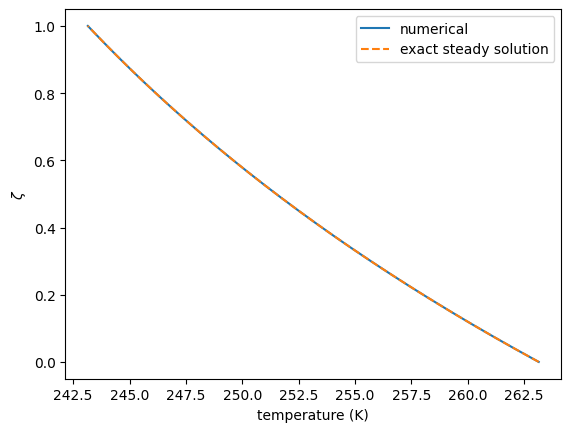

In [15]:
T_advdiff_values = np.array(
    [float(T_a.at(point)) for point in points]
)

T_exact_values = (
    T_bottom_value
    + (T_surface_value - T_bottom_value)
    * (np.exp(alpha * zeta_plot) - 1.0)
    / (np.exp(alpha) - 1.0)
)

plt.figure()
plt.plot(T_advdiff_values, zeta_plot, label="numerical")
plt.plot(
    T_exact_values,
    zeta_plot,
    "--",
    label="exact steady solution",
)
plt.xlabel("temperature (K)")
plt.ylabel(r"$\zeta$")
plt.legend()
plt.show()